# EL-GHALI MOHAMED

# Régression Linéaire Simple avec PyTorch (Données Brutes)



In [37]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. Création du Dataset (Expérience vs Salaire)
# ==========================================

# Données simulées :
data_dict = {
    "Experience_Years": [1, 3, 5, 8, 10, 12, 15, 18, 20, 25],
    "Salary_Euros": [35000, 42000, 48000, 60000, 70000, 75000, 90000, 105000, 115000, 135000]
}
# Conversion en DataFrame Pandas pour faciliter la manipulation
data = pd.DataFrame(data_dict)
data.head()

,Experience_Years,Salary_Euros
0,1,35000
1,3,42000
2,5,48000
3,8,60000
4,10,70000


## 2. Préparation des Tenseurs

PyTorch est très strict sur les dimensions. La couche `nn.Linear` attend des matrices colonnes pour les entrées de type `(n_echantillons, n_caracteristiques)`. Nous utilisons donc `.view(-1, 1)` pour forcer nos vecteurs 1D bruts à prendre la forme d'une matrice colonne. Nous utilisons `float32` (le standard) pour les calculs.

In [38]:
# Extraction des variables brutes
X_raw = data["Experience_Years"].values
Y_raw = data["Salary_Euros"].values

# Conversion en tenseurs PyTorch et redimensionnement en matrice colonne
X = torch.tensor(X_raw, dtype=torch.float32).view(-1, 1)
Y = torch.tensor(Y_raw, dtype=torch.float32).view(-1, 1)

## 3. Définition du Modèle et des Hyperparamètres

1. Nous initialisons le poids et le biais à zéro avec `torch.no_grad()`. Si PyTorch initialise par hasard un poids négatif, la première prédiction de salaire serait négative, créant une erreur démesurée face à nos cibles positives.
2. Le `lr` est réglé sur `1e-6` (0.000001).
3. Nous ferons **11 000 itérations** pour laisser au modèle le temps d'apprendre avec ces petits "pas".

In [39]:
# Définition du modèle : une couche linéaire simple (1 entrée -> 1 sortie)
model = torch.nn.Linear(in_features=1, out_features=1, dtype=torch.float32)

# Initialisation prudente à zéro
with torch.no_grad():
    model.weight.fill_(0.0)
    model.bias.fill_(0.0)

# Fonction de perte (Erreur Quadratique Moyenne) et Optimiseur (SGD)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-6)

## 4. Boucle d'entraînement

In [40]:
losses = []
iterations = 11000

print("Début de l'entraînement...")

# Boucle d'entraînement standard
for epoch in range(iterations):
    # 1: Remise à zéro des gradients
    optimizer.zero_grad()

    # 2: Prédictions
    output = model(X)

    # 3: Calcul de l'erreur
    loss = criterion(output, Y)

    # 4: Rétropropagation
    loss.backward()

    # 5: Mise à jour des paramètres
    optimizer.step()

    losses.append(loss.item())

    # Affichage régulier pour vérifier que la loss n'explose pas
    if epoch % 4000 == 0 or epoch == iterations - 1:
        print(f"Epoch {epoch:5} | MSE Loss: {loss.item():.2f}")

Début de l'entraînement...
Epoch     0 | MSE Loss: 6999299584.00
Epoch  4000 | MSE Loss: 529873504.00
Epoch  8000 | MSE Loss: 231387728.00
Epoch 10999 | MSE Loss: 217742416.00


## 5. Visualisation

Nous traçons la droite de régression trouvée. On remarque qu'elle suit parfaitement la tendance, bien que nos axes aient des valeurs massives.


Équation trouvée : Salaire = 5828.73 * Années + 528.29


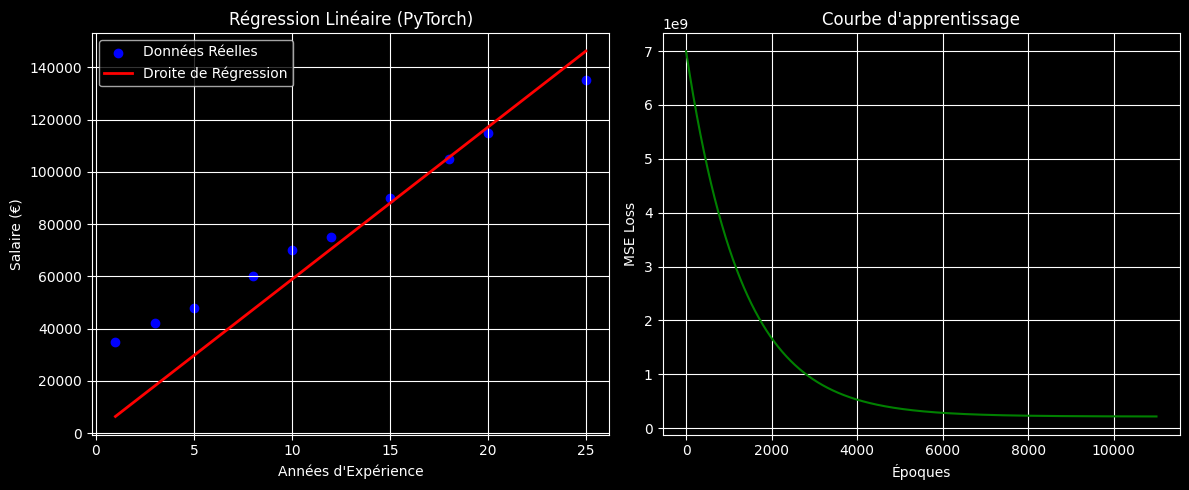

In [41]:
# Récupération du poids (le multiplicateur) et du biais (le salaire de base)
a = model.weight.item()
b = model.bias.item()

print(f"\nÉquation trouvée : Salaire = {a:.2f} * Années + {b:.2f}")

plt.figure(figsize=(12, 5))

# --- Graphique de la Régression ---
plt.subplot(1, 2, 1)
plt.scatter(X_raw, Y_raw, color="blue", label="Données Réelles")

# On utilise .detach().numpy() pour extraire les prédictions du graphe de calcul
Y_pred = model(X).detach().numpy()
plt.plot(X_raw, Y_pred, color="red", linewidth=2, label="Droite de Régression")

plt.xlabel("Années d'Expérience")
plt.ylabel("Salaire (€)")
plt.title("Régression Linéaire (PyTorch)")
plt.legend()
plt.grid(True)

# --- Graphique de la Perte (Loss) ---
plt.subplot(1, 2, 2)
plt.plot(losses, color="green")
plt.xlabel("Époques")
plt.ylabel("MSE Loss")
plt.title("Courbe d'apprentissage")
plt.grid(True)

plt.tight_layout()
plt.show()